In [ ]:
!pip install jax "jax[cuda13]" transformers huggingface_hub einops

# Variational Autoencoder (VAE)

**Paper:** [arXiv:1312.6114](https://arxiv.org/abs/1312.6114) — *Auto-Encoding Variational Bayes* (Kingma & Welling, 2013).  
**HF source:** [stabilityai/sd-vae-ft-mse](https://huggingface.co/stabilityai/sd-vae-ft-mse)

This notebook is a **from-scratch JAX implementation** of the SD VAE — the same encoder/decoder used in Stable Diffusion to compress images into a compact latent space before diffusion.

---

### What a VAE does

A VAE learns two things simultaneously:
- **Encoder** — compresses an image `(1, 3, H, W)` into a small latent `(1, 4, H/8, W/8)`
- **Decoder** — reconstructs the image from that latent

The "variational" part means the encoder outputs a *distribution* (mean + log-variance) rather than a single point. During training this regularises the latent space to be smooth and contiguous. At inference we usually just take the mean.

### Architecture at a glance

```
Image (1, 3, 512, 512)
  ↓  Conv In  →  (1, 128, 512, 512)
  ↓  4× DownBlock (ResNet × 2 + optional Downsample)
  ↓  MidBlock (ResNet → Attention → ResNet)
  ↓  Conv Out + GroupNorm
  ↓  Quant Conv  →  moments (1, 8, 64, 64)
  ↓  Split → mean (1, 4, 64, 64) = z       ← latent
  ↓  Post-Quant Conv → (1, 128, 64, 64)
  ↓  MidBlock (ResNet → Attention → ResNet)
  ↓  4× UpBlock (ResNet × 3 + optional Upsample)
  ↓  Conv Out + GroupNorm
  ↓  Reconstructed Image (1, 3, 512, 512)
```

### Imports

In [ ]:
import json
from dataclasses import dataclass
from typing import Optional

import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
from jax import tree_util
import PIL.Image as Image
from safetensors.numpy import load_file
from transformers import AutoTokenizer
from einops import rearrange, repeat

**Setup:** Download the model weights and config from HuggingFace and place them at `models/vae/` relative to your workspace root

In [ ]:
HF_REPO_ID = "stabilityai/sd-vae-ft-mse"
LOCAL_DIR_PATH = "workspace/models/vae"

In this section, we download the weights of the model of interest from huggingface to use in our implementation.

In [ ]:
from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir=LOCAL_DIR_PATH,
)
print(f"Downloaded repository path: {local_dir}")

### Load Weights

We load the pre-trained weights from a `.safetensors` file. All tensors are converted to `bfloat16` and moved into JAX arrays — the HuggingFace checkpoint uses PyTorch tensors, so a quick `.detach().cpu().numpy()` bridge is needed.

In [ ]:
WEIGHTS_PATH = f"{LOCAL_DIR_PATH}/diffusion_pytorch_model.safetensors"
CONFIG_PATH = f"{LOCAL_DIR_PATH}/config.json"
MODEL_PATH = LOCAL_DIR_PATH
IMAGE_PATH = f"{LOCAL_DIR_PATH}/building.png"

# Load the raw state dict
hf_weights = load_file(WEIGHTS_PATH)

### Inspect Weights

A quick sanity check — print every key and its shape. This tells us exactly what sub-modules exist (encoder, decoder, quant/post-quant convs) and helps us map HuggingFace name conventions to our own dict structure.

In [4]:
for key, value in hf_weights.items():
    print(f"{key:<60}: {value.shape}")

decoder.conv_in.bias                                        : torch.Size([512])
decoder.conv_in.weight                                      : torch.Size([512, 4, 3, 3])
decoder.conv_norm_out.bias                                  : torch.Size([128])
decoder.conv_norm_out.weight                                : torch.Size([128])
decoder.conv_out.bias                                       : torch.Size([3])
decoder.conv_out.weight                                     : torch.Size([3, 128, 3, 3])
decoder.mid_block.attentions.0.group_norm.bias              : torch.Size([512])
decoder.mid_block.attentions.0.group_norm.weight            : torch.Size([512])
decoder.mid_block.attentions.0.key.bias                     : torch.Size([512])
decoder.mid_block.attentions.0.key.weight                   : torch.Size([512, 512])
decoder.mid_block.attentions.0.proj_attn.bias               : torch.Size([512])
decoder.mid_block.attentions.0.proj_attn.weight             : torch.Size([512, 512])
decoder.mid_bl

### Config

A simple dataclass to hold architectural constants. The SD VAE uses 4 encoder down-blocks and 4 decoder up-blocks — this controls how many times we halve (or double) the spatial resolution.

In [5]:
@dataclass
class Config:
    num_encoder_layers: int = 4
    num_decoder_layers: int = 4

config = Config()

### Weight Extraction

We use `hf_weights.pop(name)` to pull each tensor out of the HuggingFace checkpoint and organise everything into clean nested Python dicts (`encoder_blocks`, `decoder_blocks`, `m`).

`pop` is intentional — after this cell runs, `hf_weights` should be empty, which proves we've accounted for every parameter (verified with the `hf_weights.keys()` check after).

In [ ]:
def get_w(
    name: str,
    transpose: bool = False
):
    val = hf_weights.pop(name)
    w = jnp.array(val.detach().cpu(), dtype=jnp.bfloat16)
    return w.T if transpose else w

encoder_blocks = {
    'mid_block': {},
    'conv': {},
    'down_blocks': []
}

decoder_blocks = {
    'mid_block': {},
    'conv': {},
    'up_blocks': []
}

encoder_blocks['mid_block'] = {
    'attention': {
        'key': {
            'weight': get_w("encoder.mid_block.attentions.0.key.weight"),
            'bias': get_w("encoder.mid_block.attentions.0.key.bias")
        },
        'query': {
            'weight': get_w("encoder.mid_block.attentions.0.query.weight"),
            'bias': get_w("encoder.mid_block.attentions.0.query.bias")
        },
        'value': {
            'weight': get_w("encoder.mid_block.attentions.0.value.weight"),
            'bias': get_w("encoder.mid_block.attentions.0.value.bias")
        },
        'proj': {
            'weight': get_w("encoder.mid_block.attentions.0.proj_attn.weight"),
            'bias': get_w("encoder.mid_block.attentions.0.proj_attn.bias")
        },
        'group_norm': {
            'weight': get_w("encoder.mid_block.attentions.0.group_norm.weight"),
            'bias': get_w("encoder.mid_block.attentions.0.group_norm.bias")
        }
    },
    'resnets': [
        {
            'conv1': {
                'weight': get_w(f"encoder.mid_block.resnets.{i}.conv1.weight"),
                'bias': get_w(f"encoder.mid_block.resnets.{i}.conv1.bias")
            },
            'conv2': {
                'weight': get_w(f"encoder.mid_block.resnets.{i}.conv2.weight"),
                'bias': get_w(f"encoder.mid_block.resnets.{i}.conv2.bias")
            },
            'norm1': {
                'weight': get_w(f"encoder.mid_block.resnets.{i}.norm1.weight"),
                'bias': get_w(f"encoder.mid_block.resnets.{i}.norm1.bias")
            },
            'norm2': {
                'weight': get_w(f"encoder.mid_block.resnets.{i}.norm2.weight"),
                'bias': get_w(f"encoder.mid_block.resnets.{i}.norm2.bias")
            }
        } for i in range(2)
    ]
}

encoder_blocks['conv'] = {
    'in': {
        'weight': get_w("encoder.conv_in.weight"),
        'bias': get_w("encoder.conv_in.bias")
    },
    'norm': {
        'weight': get_w("encoder.conv_norm_out.weight"),
        'bias': get_w("encoder.conv_norm_out.bias")
    },
    'out': {
        'weight': get_w("encoder.conv_out.weight"),
        'bias': get_w("encoder.conv_out.bias")
    }
}

decoder_blocks['mid_block'] = {
    'attention': {
        'key': {
            'weight': get_w("decoder.mid_block.attentions.0.key.weight"),
            'bias': get_w("decoder.mid_block.attentions.0.key.bias")
        },
        'query': {
            'weight': get_w("decoder.mid_block.attentions.0.query.weight"),
            'bias': get_w("decoder.mid_block.attentions.0.query.bias")
        },
        'value': {
            'weight': get_w("decoder.mid_block.attentions.0.value.weight"),
            'bias': get_w("decoder.mid_block.attentions.0.value.bias")
        },
        'proj': {
            'weight': get_w("decoder.mid_block.attentions.0.proj_attn.weight"),
            'bias': get_w("decoder.mid_block.attentions.0.proj_attn.bias")
        },
        'group_norm': {
            'weight': get_w("decoder.mid_block.attentions.0.group_norm.weight"),
            'bias': get_w("decoder.mid_block.attentions.0.group_norm.bias")
        }
    },
    'resnets': [
        {
            'conv1': {
                'weight': get_w(f"decoder.mid_block.resnets.{i}.conv1.weight"),
                'bias': get_w(f"decoder.mid_block.resnets.{i}.conv1.bias")
            },
            'conv2': {
                'weight': get_w(f"decoder.mid_block.resnets.{i}.conv2.weight"),
                'bias': get_w(f"decoder.mid_block.resnets.{i}.conv2.bias")
            },
            'norm1': {
                'weight': get_w(f"decoder.mid_block.resnets.{i}.norm1.weight"),
                'bias': get_w(f"decoder.mid_block.resnets.{i}.norm1.bias")
            },
            'norm2': {
                'weight': get_w(f"decoder.mid_block.resnets.{i}.norm2.weight"),
                'bias': get_w(f"decoder.mid_block.resnets.{i}.norm2.bias")
            }
        } for i in range(2)
    ]
}

decoder_blocks['conv'] = {
    'in': {
        'weight': get_w("decoder.conv_in.weight"),
        'bias': get_w("decoder.conv_in.bias")
    },
    'norm': {
        'weight': get_w("decoder.conv_norm_out.weight"),
        'bias': get_w("decoder.conv_norm_out.bias")
    },
    'out': {
        'weight': get_w("decoder.conv_out.weight"),
        'bias': get_w("decoder.conv_out.bias")
    }
}

for block in range(config.num_encoder_layers):
    encoder_blocks['down_blocks'].append({
        'downsamplers': {
            'weight': get_w(f"encoder.down_blocks.{block}.downsamplers.0.conv.weight"),
            'bias': get_w(f"encoder.down_blocks.{block}.downsamplers.0.conv.bias")
        } if block < config.num_encoder_layers - 1 else None,
        'resnets': [
            {
                'conv1': {
                    'weight': get_w(f"encoder.down_blocks.{block}.resnets.{i}.conv1.weight"),
                    'bias': get_w(f"encoder.down_blocks.{block}.resnets.{i}.conv1.bias")
                },
                'conv2': {
                    'weight': get_w(f"encoder.down_blocks.{block}.resnets.{i}.conv2.weight"),
                    'bias': get_w(f"encoder.down_blocks.{block}.resnets.{i}.conv2.bias")
                },
                'norm1': {
                    'weight': get_w(f"encoder.down_blocks.{block}.resnets.{i}.norm1.weight"),
                    'bias': get_w(f"encoder.down_blocks.{block}.resnets.{i}.norm1.bias")
                },
                'norm2': {
                    'weight': get_w(f"encoder.down_blocks.{block}.resnets.{i}.norm2.weight"),
                    'bias': get_w(f"encoder.down_blocks.{block}.resnets.{i}.norm2.bias")
                },
                'conv_shortcut': {
                    'weight': get_w(f"encoder.down_blocks.{block}.resnets.{i}.conv_shortcut.weight"),
                    'bias': get_w(f"encoder.down_blocks.{block}.resnets.{i}.conv_shortcut.bias")
                } if (block in [1,2] and i == 0) else None
            } for i in range(2)
        ]
    })

    decoder_blocks['up_blocks'].append({
        'upsamplers': {
            'weight': get_w(f"decoder.up_blocks.{block}.upsamplers.0.conv.weight"),
            'bias': get_w(f"decoder.up_blocks.{block}.upsamplers.0.conv.bias")
        } if block < config.num_decoder_layers - 1 else None,
        'resnets': [
            {
                'conv1': {
                    'weight': get_w(f"decoder.up_blocks.{block}.resnets.{i}.conv1.weight"),
                    'bias': get_w(f"decoder.up_blocks.{block}.resnets.{i}.conv1.bias")
                },
                'conv2': {
                    'weight': get_w(f"decoder.up_blocks.{block}.resnets.{i}.conv2.weight"),
                    'bias': get_w(f"decoder.up_blocks.{block}.resnets.{i}.conv2.bias")
                },
                'norm1': {
                    'weight': get_w(f"decoder.up_blocks.{block}.resnets.{i}.norm1.weight"),
                    'bias': get_w(f"decoder.up_blocks.{block}.resnets.{i}.norm1.bias")
                },
                'norm2': {
                    'weight': get_w(f"decoder.up_blocks.{block}.resnets.{i}.norm2.weight"),
                    'bias': get_w(f"decoder.up_blocks.{block}.resnets.{i}.norm2.bias")
                },
                'conv_shortcut': {
                    'weight': get_w(f"decoder.up_blocks.{block}.resnets.{i}.conv_shortcut.weight"),
                    'bias': get_w(f"decoder.up_blocks.{block}.resnets.{i}.conv_shortcut.bias")
                } if (block in [2,3] and i == 0) else None
            } for i in range(3)
        ]
    })

m = {
    'quant': {
        'weight': get_w("quant_conv.weight"),
        'bias': get_w("quant_conv.bias")
    },
    'post_quant': {
        'weight': get_w("post_quant_conv.weight"),
        'bias': get_w("post_quant_conv.bias")
    },
    'encoder': encoder_blocks,
    'decoder': decoder_blocks
}


In [7]:
hf_weights.keys()

dict_keys([])

### Preprocessing

Before feeding an image to the encoder we need to:
1. **Square-crop** — centre-crop to the smaller dimension so no distortion occurs
2. **Resize** to `512×512` (the resolution this VAE was trained at)
3. **Normalise** from `[0, 255]` → `[-1, 1]` (the SD convention)
4. **Add batch dim and transpose** to channels-first format: `(H, W, C)` → `(1, C, H, W)`

In [8]:
def preprocess_vae(
    image_path: str,
    target_size: int = 512
):
    img = Image.open(image_path).convert("RGB")

    width, height = img.size
    min_dim = min(width, height)
    left = (width - min_dim) / 2
    top = (height - min_dim) / 2
    right = (width + min_dim) / 2
    bottom = (height + min_dim) / 2

    img = img.crop((left, top, right, bottom))
    img = img.resize((target_size, target_size), resample=Image.LANCZOS)

    x = jnp.array(img).astype(jnp.bfloat16) / 255.0
    x = (x * 2.0) - 1.0
    x = rearrange(x, 'h w c -> 1 c h w')

    return x


### Group Norm

The VAE uses **Group Normalisation** (instead of Batch Norm) for stability at small batch sizes. It splits the `C` channels into `G=32` groups and normalises within each group independently — no dependency on batch size.

```
x: (N, C, H, W) →  reshape to (N, G, C//G, H, W)
                →  normalise over axes (C//G, H, W)
                →  reshape back to (N, C, H, W)
                →  apply learned scale (γ) and shift (β)
```

In [9]:
def group_norm(
    x: jnp.ndarray,        # (N, C, H, W)
    weight: jnp.ndarray,   # (C,)
    bias: jnp.ndarray,     # (C,)
    num_groups: int = 32,
    eps: float = 1e-6
):
    batch, channels, height, width = x.shape

    x = x.reshape((batch, num_groups, channels // num_groups, height, width))

    var_axes = (2, 3, 4)
    mean = jnp.mean(x, axis=var_axes, keepdims=True)
    var = jnp.var(x, axis=var_axes, keepdims=True)

    x = (x - mean) * jax.lax.rsqrt(var + eps)

    x = x.reshape((batch, channels, height, width))

    scale = weight[None, :, None, None]
    shift = bias[None, :, None, None]

    return x * scale + shift


### ResNet Block

The core building block of both the encoder and decoder. It's a standard **pre-activation ResNet** residual block:

```
x ──────────────────────────────────► (+) ── out
  │                                    ▲
  ▼                                    │
GroupNorm → SiLU → Conv3×3             │ (optional 1×1 conv_shortcut
GroupNorm → SiLU → Conv3×3 ────────────┘  if in/out channels differ)
```

The shortcut conv is only present at the first block of down/up stages where the channel count changes.

In [10]:
def resnet_block(
    x: jnp.ndarray,    # (N, C, H, W)
    w_dict: dict
):
    residual = x

    x = group_norm(x, w_dict['norm1']['weight'], w_dict['norm1']['bias'])
    x = jnn.silu(x)
    x = jax.lax.conv_general_dilated(
        x,
        w_dict['conv1']['weight'],
        window_strides=(1, 1),
        padding='SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    ) + w_dict['conv1']['bias'][:, None, None]

    x = group_norm(x, w_dict['norm2']['weight'], w_dict['norm2']['bias'])
    x = jnn.silu(x)
    x = jax.lax.conv_general_dilated(
        x,
        w_dict['conv2']['weight'],
        window_strides=(1, 1),
        padding='SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    ) + w_dict['conv2']['bias'][:, None, None]

    if w_dict.get('conv_shortcut', None) is not None:
        shortcut_w = w_dict['conv_shortcut']['weight']
        shortcut_b = w_dict['conv_shortcut']['bias']
        residual = jax.lax.conv_general_dilated(
            residual,
            shortcut_w,
            window_strides=(1, 1),
            padding='SAME',
            dimension_numbers=('NCHW', 'OIHW', 'NCHW')
        ) + shortcut_b[:, None, None]

    return x + residual


### Spatial Self-Attention

Applied once in the middle of both encoder and decoder (the **mid-block**). Because the spatial map at that point is `64×64`, we can afford a single-head self-attention over all `64×64 = 4096` positions.

The implementation flattens spatial dimensions and performs:

```
Q, K, V = linear projections of GroupNorm(x)          # (B, C, HW)
Attn    = softmax( Qᵀ K / √C )                        # (B, HW, HW)
out     = V · Attnᵀ                                   # (B, C, HW)
x       = x + proj(out)                               # residual
```

This is the mechanism that lets the encoder/decoder reason about global structure — without it the model would be purely local (convolution only).

In [11]:
def spatial_attention(
    x: jnp.ndarray,    # (1, 512, 64, 64)
    params: dict
):
    b, c, h, w = x.shape

    h_norm = group_norm(x, params['group_norm']['weight'], params['group_norm']['bias'])

    q = jnp.einsum('bchw,oc->bohw', h_norm, params['query']['weight']) + params['query']['bias'][:, None, None]
    k = jnp.einsum('bchw,oc->bohw', h_norm, params['key']['weight']) + params['key']['bias'][:, None, None]
    v = jnp.einsum('bchw,oc->bohw', h_norm, params['value']['weight']) + params['value']['bias'][:, None, None]

    q = q.reshape(b, c, -1)
    k = k.reshape(b, c, -1)
    v = v.reshape(b, c, -1)

    attn = jnp.matmul(q.transpose(0, 2, 1), k)
    attn = attn * (c ** -0.5)
    attn = jax.nn.softmax(attn, axis=-1)

    out = jnp.matmul(v, attn.transpose(0, 2, 1))
    out = out.reshape(b, c, h, w)

    out = jnp.einsum('bchw,oc->bohw', out, params['proj']['weight']) + params['proj']['bias'][:, None, None]

    return x + out


### Encoder

The encoder progressively **compresses** the image through four down-blocks, each halving the spatial resolution, then passes through a mid-block.

| Stage | Block | Spatial | Channels |
|---|---|---|---|
| Input | Conv In | 512×512 | 128 |
| Down 0 | 2× ResNet | 512×512 | 128 |
| Down 1 | 2× ResNet + ↓ | 256×256 | 256 |
| Down 2 | 2× ResNet + ↓ | 128×128 | 512 |
| Down 3 | 2× ResNet + ↓ | 64×64 | 512 |
| Mid | ResNet → Attn → ResNet | 64×64 | 512 |
| Out | GroupNorm + SiLU + Conv | 64×64 | 8 |

The final `8` channels are split into `mean` and `log_var` — each 4 channels — representing the latent distribution.

In [12]:
def encoder_downblocks(
    x: jnp.ndarray,    # (1, 128, 512, 512)
    blocks: list
):
    for block_idx, block in enumerate(blocks):
        for resnet_w in block['resnets']:
            x = resnet_block(x, resnet_w)

        if block['downsamplers'] is not None:
            w_down = block['downsamplers']['weight']
            b_down = block['downsamplers']['bias']

            x = jax.lax.conv_general_dilated(
                x,
                w_down,
                window_strides=(2, 2),
                padding=((0,1), (0,1)),
                dimension_numbers=('NCHW', 'OIHW', 'NCHW')
            ) + b_down[None, :, None, None]

    return x

def encoder_midblock(
    x: jnp.ndarray,    # (1, 512, 64, 64)
    mid_block: dict
):
    x = resnet_block(x, mid_block['resnets'][0])

    x = spatial_attention(x, mid_block['attention'])

    x = resnet_block(x, mid_block['resnets'][1])

    return x

def encoder_conv(
    x: jnp.ndarray,    # (1, 512, 64, 64)
    conv_params: dict
):
    x = group_norm(x, conv_params['norm']['weight'], conv_params['norm']['bias'])
    x = x * jax.nn.sigmoid(x)

    w_out = conv_params['out']['weight']
    b_out = conv_params['out']['bias']

    x = jax.lax.conv_general_dilated(
        x,
        w_out,
        window_strides=(1, 1),
        padding='SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    ) + b_out[None, :, None, None]

    return x


### Latent Space — Quantization & Sampling

The encoder's `8`-channel output is passed through a `1×1` **quant conv** — a learned linear projection that compresses the representation before splitting.

`split_latent` divides the `8` channels into `mean` and `log_var` (4 each), then either:
- **Samples** a point `z = mean + std * ε` (stochastic, used during training)
- **Returns the mean directly** (deterministic, used at inference — the default with `rng_key=None`)

This is the reparameterisation trick from the VAE paper: backprop flows through `mean` and `std`, not through the random sample itself.

In [13]:
def encoder_exit(
    x: jnp.ndarray,    # (1, 8, 64, 64)
    params: dict
):
    w_q = params['quant']['weight']
    b_q = params['quant']['bias']

    moments = jax.lax.conv_general_dilated(
        x,
        w_q,
        window_strides=(1, 1),
        padding='SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    ) + b_q[None, :, None, None]

    return moments

def split_latent(
    moments: jnp.ndarray,              # (1, 8, 64, 64)
    rng_key: Optional[jax.Array] = None
):
    mean, logvar = jnp.split(moments, 2, axis=1)

    if rng_key is not None:
        logvar = jnp.clip(logvar, -30.0, 20.0)
        std = jnp.exp(0.5 * logvar)
        eps = jax.random.normal(rng_key, mean.shape, dtype=mean.dtype)
        z = mean + std * eps
    else:
        z = mean

    return z, mean, logvar


### Encoder — Full Forward Pass

Wires everything together: conv-in → down-blocks → mid-block → conv-out → quant conv → split into `z`. Returns just `z` (the latent), discarding `mean` and `logvar` (they're only needed for the KL loss during training).

In [14]:
def encoder_forward(
    x: jnp.ndarray,                        # (1, 3, 512, 512)
    params: dict,
    rng_key: Optional[jax.Array] = None
):
    w_in = params['encoder']['conv']['in']['weight']
    b_in = params['encoder']['conv']['in']['bias']

    x = jax.lax.conv_general_dilated(
        x,
        w_in,
        window_strides=(1, 1),
        padding='SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    ) + b_in[None, :, None, None]

    x = encoder_downblocks(x, params['encoder']['down_blocks'])

    x = encoder_midblock(x, params['encoder']['mid_block'])

    x = encoder_conv(x, params['encoder']['conv'])

    moments = encoder_exit(x, params)

    z, mean, logvar = split_latent(moments, rng_key)

    return z


### Decoder

The decoder is an **exact mirror** of the encoder — but instead of down-sampling, it up-samples. The latent `z` enters through a post-quant conv and an initial conv-in, then passes through a mid-block and four up-blocks.

| Stage | Block | Spatial | Channels |
|---|---|---|---|
| Entry | Post-Quant Conv + Conv In | 64×64 | 512 |
| Mid | ResNet → Attn → ResNet | 64×64 | 512 |
| Up 0 | 3× ResNet + ↑ | 128×128 | 512 |
| Up 1 | 3× ResNet + ↑ | 256×256 | 512 |
| Up 2 | 3× ResNet + ↑ | 512×512 | 256 |
| Up 3 | 3× ResNet | 512×512 | 128 |
| Out | GroupNorm + SiLU + Conv | 512×512 | 3 |

In [15]:
def decoder_entry(
    z: jnp.ndarray,    # (1, 4, 64, 64)
    params: dict
):
    w_pq = params['post_quant']['weight']
    b_pq = params['post_quant']['bias']

    x = jax.lax.conv_general_dilated(
        z,
        w_pq,
        window_strides=(1, 1),
        padding='SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    ) + b_pq[None, :, None, None]

    w_in = params['decoder']['conv']['in']['weight']
    b_in = params['decoder']['conv']['in']['bias']
    x = jax.lax.conv_general_dilated(
        x,
        w_in,
        window_strides=(1, 1),
        padding='SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    ) + b_in[None, :, None, None]

    return x


### Upsample Layer

Instead of transposed convolutions (which produce checkerboard artefacts), the decoder uses **nearest-neighbour resize followed by a regular conv** — a technique popularised by [Odena et al. 2016](https://distill.pub/2016/deconv-checkerboard/). The `2×` resize doubles the spatial size, and the conv smooths the result.

In [16]:
def upsample_layer(
    x: jnp.ndarray,    # (N, C, H, W)
    params: dict
):
    weights = params['weight']
    bias = params['bias']

    b, c, h, w = x.shape
    x = jax.image.resize(x, (b, c, h * 2, w * 2), method='nearest')

    return jax.lax.conv_general_dilated(
        x,
        weights,
        window_strides=(1, 1),
        padding='SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    ) + bias[None, :, None, None]


### Decoder Blocks

The decoder has 3 sub-functions that mirror the encoder:

- **`decoder_upblocks`** — loops through 4 up-blocks, each running 3 ResNet blocks followed by an optional `upsample_layer`
- **`decoder_midblock`** — the bottleneck: ResNet → Attention → ResNet at `64×64`  
- **`decoder_conv`** — final GroupNorm + SiLU + `3×3` conv that projects back to 3 RGB channels

In [17]:
def decoder_upblocks(
    x: jnp.ndarray,    # (1, 512, 64, 64)
    blocks: list
):
    for block_idx, block in enumerate(blocks):
        for resnet_w in block['resnets']:
            x = resnet_block(x, resnet_w)

        if block['upsamplers'] is not None:
            x = upsample_layer(x, block['upsamplers'])

    return x

def decoder_midblock(
    x: jnp.ndarray,    # (1, 512, 64, 64)
    mid_block: dict
):
    x = resnet_block(x, mid_block['resnets'][0])

    x = spatial_attention(x, mid_block['attention'])

    x = resnet_block(x, mid_block['resnets'][1])

    return x

def decoder_conv(
    x: jnp.ndarray,    # (1, 128, 512, 512)
    conv_params: dict
):
    x = group_norm(x, conv_params['norm']['weight'], conv_params['norm']['bias'])
    x = x * jax.nn.sigmoid(x)

    w_out = conv_params['out']['weight']
    b_out = conv_params['out']['bias']

    x = jax.lax.conv_general_dilated(
        x,
        w_out,
        window_strides=(1, 1),
        padding='SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    ) + b_out[None, :, None, None]

    return x


### Decoder — Full Forward Pass

Wires the decoder together: entry (post-quant + conv-in) → mid-block → up-blocks → final conv. Returns the reconstructed image in `[-1, 1]` before postprocessing.

In [18]:
def decoder_full_pass(
    z: jnp.ndarray,    # (1, 4, 64, 64)
    params: dict
):
    x = decoder_entry(z, params)

    x = decoder_midblock(x, params['decoder']['mid_block'])

    x = decoder_upblocks(x, params['decoder']['up_blocks'])

    x = decoder_conv(x, params['decoder']['conv'])

    return x


### Encode & Decode

Run the full pipeline end-to-end. We encode the image into a `(1, 4, 64, 64)` latent, then decode it back. The output shape should match the input — `(1, 3, 512, 512)` — confirming the round-trip works correctly.

In [19]:
image = preprocess_vae(IMAGE_PATH)
result = encoder_forward(image, m)
result.shape

(1, 4, 64, 64)

In [20]:
image_out = decoder_full_pass(result, m)
image_out.shape

(1, 3, 512, 512)

### Postprocessing & Visualisation

Convert the decoder output back to a displayable image:
1. **Remove batch dim** — `(1, C, H, W)` → `(C, H, W)`
2. **Rescale** from `[-1, 1]` → `[0, 1]`
3. **Clip** to handle any floating-point overshoot
4. **Transpose** from channels-first to HWC — `(C, H, W)` → `(H, W, C)` for `imshow`

In [21]:
import matplotlib.pyplot as plt

def postprocess_vae(
    x: jnp.ndarray    # (1, 3, 512, 512)
):
    x = jnp.squeeze(x, axis=0)

    x = (x + 1.0) / 2.0

    x = jnp.clip(x, 0.0, 1.0)

    x = jnp.transpose(x, (1, 2, 0))

    return x


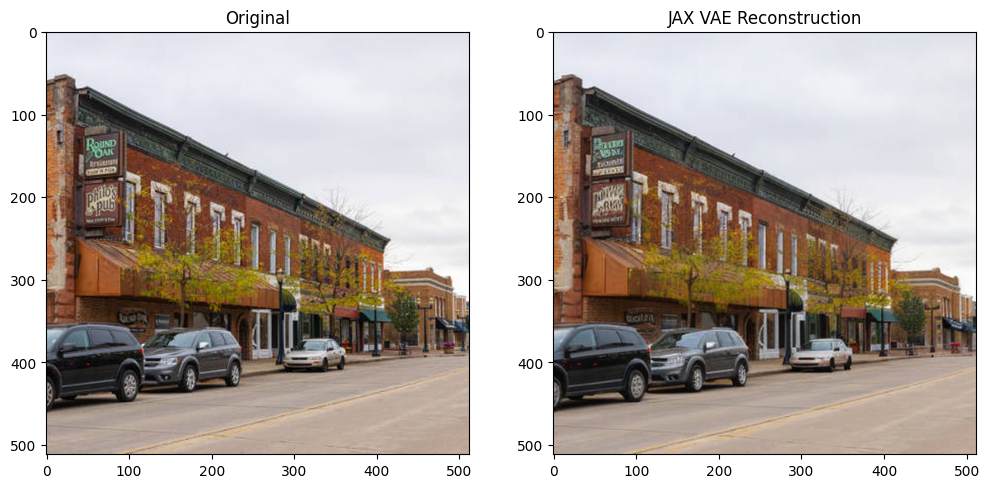

In [22]:
reconstructed_img = postprocess_vae(image_out.astype(jnp.float32))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(postprocess_vae(image.astype(jnp.float32)))

plt.subplot(1, 2, 2)
plt.title("JAX VAE Reconstruction")
plt.imshow(reconstructed_img)

plt.show()

### Reconstruction Quality — PSNR

**Peak Signal-to-Noise Ratio** measures how faithful the reconstruction is to the original. Higher is better — a perfect reconstruction gives `∞ dB`.

$$\text{PSNR} = 20 \cdot \log_{10}\!\left(\frac{1}{\sqrt{\text{MSE}}}\right)$$

Typical values for a well-trained VAE at `512×512` are in the `30–40 dB` range. The SD VAE is trained with an MSE + perceptual + adversarial loss, so it prioritises perceptual quality over pixel-perfect accuracy.

In [23]:
def calculate_psnr(
    img1: jnp.ndarray,    # (1, 3, 512, 512)
    img2: jnp.ndarray     # (1, 3, 512, 512)
):
    mse = jnp.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * jnp.log10(1.0 / jnp.sqrt(mse))


print(f"PSNR: {calculate_psnr(image, image_out)}")


PSNR: 20.5


### Visualisation 1 — Latent Channel Heatmaps

`result` is `(1, 4, 64, 64)` — 4 channels, each a `64×64` spatial map. Plotting them reveals what each channel has learned to encode. Channels tend to specialise: some capture luminance, others colour or edge information.

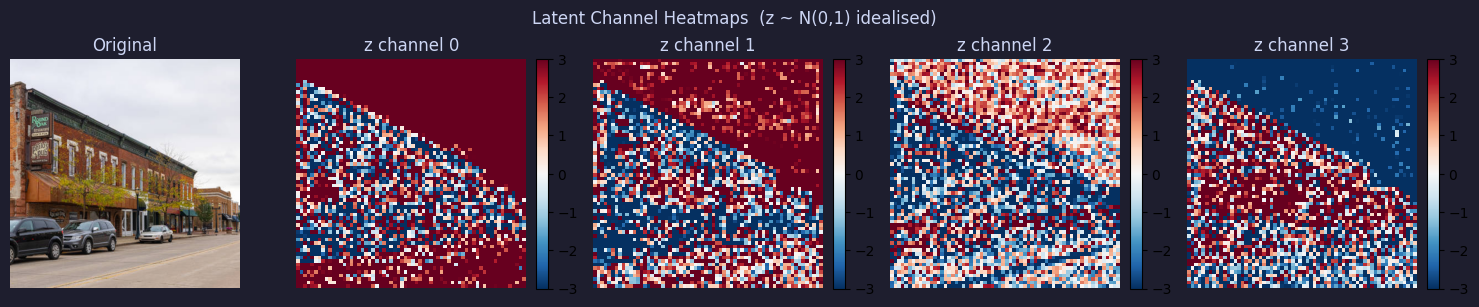

In [24]:
latent = np.array(result[0], dtype=np.float32)  # (4, 64, 64)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.patch.set_facecolor('#1e1e2e')

axes[0].imshow(postprocess_vae(image.astype(jnp.float32)))
axes[0].set_title("Original", color='#cdd6f4')
axes[0].axis('off')

for i in range(4):
    ch = latent[i]
    im = axes[i + 1].imshow(ch, cmap='RdBu_r', vmin=-3, vmax=3)
    axes[i + 1].set_title(f"z channel {i}", color='#cdd6f4')
    axes[i + 1].axis('off')
    axes[i + 1].set_facecolor('#1e1e2e')
    plt.colorbar(im, ax=axes[i + 1], fraction=0.046, pad=0.04)

plt.suptitle("Latent Channel Heatmaps  (z ~ N(0,1) idealised)", color='#cdd6f4', fontsize=12)
plt.tight_layout()
plt.show()


### Visualisation 2 — Difference Map

Shows *where* the VAE loses detail. Bright regions in the diff map are where the reconstruction diverges most from the original — typically fine textures, text, and high-frequency edges.

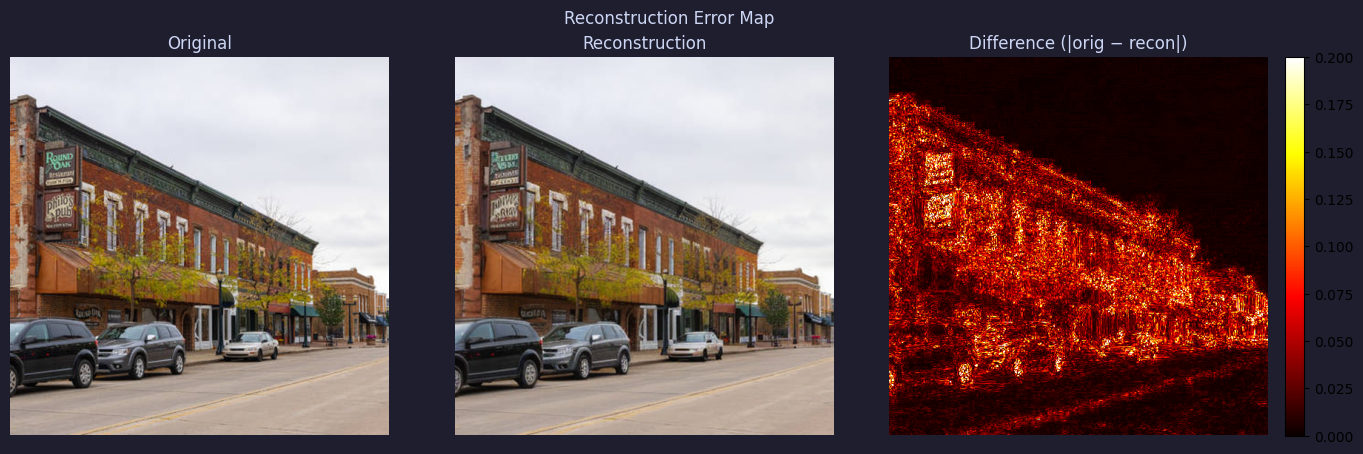

In [25]:
orig_pp  = np.array(postprocess_vae(image.astype(jnp.float32)),     dtype=np.float32)
recon_pp = np.array(postprocess_vae(image_out.astype(jnp.float32)), dtype=np.float32)

diff = np.abs(orig_pp - recon_pp)              # (512, 512, 3)
diff_gray = diff.mean(axis=-1)                 # collapse channels → (512, 512)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.patch.set_facecolor('#1e1e2e')
for ax in axes:
    ax.set_facecolor('#1e1e2e')

axes[0].imshow(orig_pp);  axes[0].set_title("Original",       color='#cdd6f4'); axes[0].axis('off')
axes[1].imshow(recon_pp); axes[1].set_title("Reconstruction", color='#cdd6f4'); axes[1].axis('off')

im = axes[2].imshow(diff_gray, cmap='hot', vmin=0, vmax=0.2)
axes[2].set_title("Difference (|orig − recon|)", color='#cdd6f4')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle("Reconstruction Error Map", color='#cdd6f4', fontsize=12)
plt.tight_layout()
plt.show()


### Visualisation 3 — Latent Perturbation

Scale `z` by a constant before decoding. A scale of `0` pushes `z` to the origin — decoded to the "average" image the decoder has memorised from its prior. Scaling above `1` amplifies deviations from the mean, exaggerating features until the image degrades.

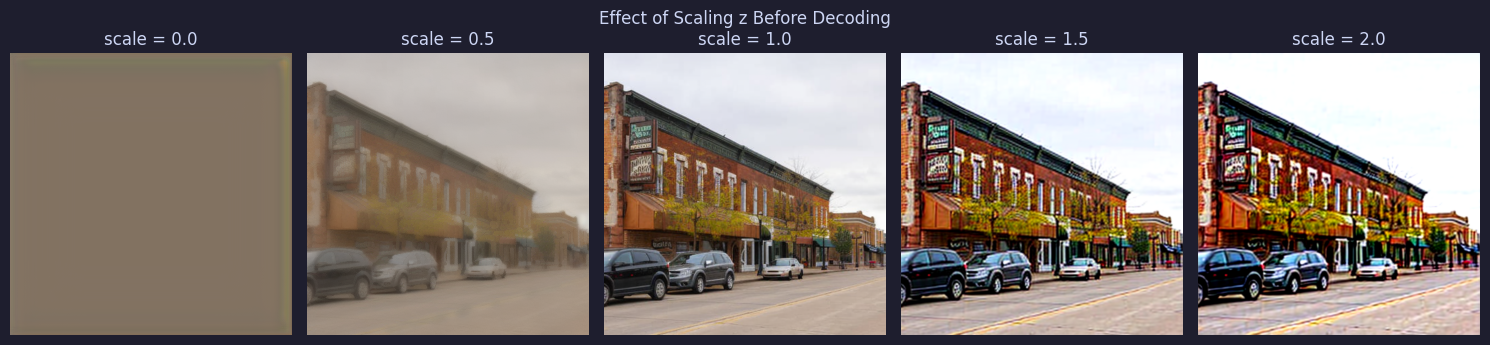

In [26]:
scales = [0.0, 0.5, 1.0, 1.5, 2.0]

fig, axes = plt.subplots(1, len(scales), figsize=(15, 3.5))
fig.patch.set_facecolor('#1e1e2e')

for ax, scale in zip(axes, scales):
    z_scaled = result * scale
    out = decoder_full_pass(z_scaled, m)
    img_pp = np.array(postprocess_vae(out.astype(jnp.float32)), dtype=np.float32)
    ax.imshow(img_pp)
    ax.set_title(f"scale = {scale}", color='#cdd6f4')
    ax.axis('off')
    ax.set_facecolor('#1e1e2e')

plt.suptitle("Effect of Scaling z Before Decoding", color='#cdd6f4', fontsize=12)
plt.tight_layout()
plt.show()


### Visualisation 4 — Latent Distribution

The VAE's KL loss regularises the latent space toward $\mathcal{N}(0, 1)$. Plotting a histogram of all values in `z` (across all 4 channels and all `64×64` positions) lets us verify this — a well-trained VAE should give a roughly Gaussian distribution centred near zero.

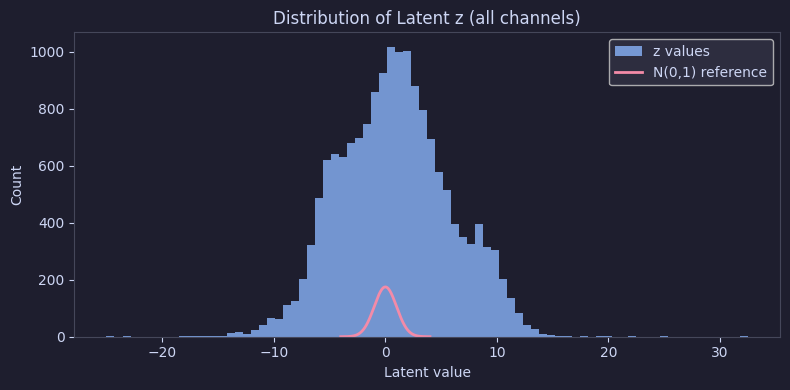

z  mean: 0.8612   std: 4.9472


In [27]:
z_flat = np.array(result, dtype=np.float32).flatten()

x_range = np.linspace(-4, 4, 300)
gaussian = np.exp(-0.5 * x_range ** 2) / np.sqrt(2 * np.pi)
gaussian *= len(z_flat) * (x_range[1] - x_range[0])   # scale to match histogram counts

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

ax.hist(z_flat, bins=80, color='#89b4fa', alpha=0.8, edgecolor='none', label='z values')
ax.plot(x_range, gaussian, color='#f38ba8', linewidth=2, label='N(0,1) reference')

ax.set_xlabel("Latent value", color='#cdd6f4')
ax.set_ylabel("Count", color='#cdd6f4')
ax.tick_params(colors='#cdd6f4')
ax.set_title("Distribution of Latent z (all channels)", color='#cdd6f4', fontsize=12)
ax.legend(facecolor='#313244', labelcolor='#cdd6f4')
for spine in ax.spines.values():
    spine.set_edgecolor('#45475a')

plt.tight_layout()
plt.show()

print(f"z  mean: {z_flat.mean():.4f}   std: {z_flat.std():.4f}")
